# Case study 1: Repuragent executes end-to-end workflow to suggest drugs to repurpose for Acute Myeloid Leukemia (AML)


This case study demonstrated the capability of Repuragent to coording long-running workflow end-to-end to suggest drugs that could be repurpose for AML, pack with traaceable evidences. This notebook is an analysis of the outputs from Repuragent, in comparision with Google Co-scientist, and Vanilla LLMs. To see the agent full run please visit:
[https://repuragent.serve.scilifelab.se](https://repuragent.serve.scilifelab.se)


---

## Notebook Structure

This notebook includes three parts:
* **Part 1:** Vanilla LLMs run and analysis
* **Part 2:** Repuragent's output analysis
* **Part 3:** Pathway enrichment and comparison with Co-scientist



In [1]:
import os
import time
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import time
from collections import defaultdict
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objects as go

load_dotenv()
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

from AML_utils import *


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Nature-style global settings
COLORS = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_theme(style="ticks")


## Part 1: Vanila LLM run and analysis

In [ ]:
# Define models to test
models_to_test = [
    'gpt-4o',
    'gpt-4o-mini',
    'gpt-5',
    'gpt-5-mini',
    'gpt-5.1',
    'gpt-5.2',
]

# Prompt 
prompt = """Suggest top 20 existing drugs that could be repurposed for acute myeloid leukemia (AML) treatment 
and provide experimentally testable concentrations for an IC50 assay. 
The drug should inhibit the proliferation of AML cell lines, particularly MOLM13.
"""

# Lists to store all results
all_results = []

# Number of iterations per model
loop_time = 10

# Outer loop over models
for model_name in models_to_test:
    print(f"\n{'#'*60}")
    print(f"Testing Model: {model_name}")
    print(f"{'#'*60}")
    
    # Initialize model
    model = ChatOpenAI(model=model_name, api_key=OPENAI_API_KEY)
    
    # Inner loop for iterations
    for i in range(loop_time):
        print(f"\n{'='*50}")
        print(f"Model: {model_name} | Iteration {i+1}/{loop_time}")
        print(f"{'='*50}")
        
        # Measure running time of vanila_repurposing
        start_time = time.time()
        repurposing_results = vanila_repurposing(
            model, 
            prompt,
            output_file=f'vanila_LLM_output/results_{model_name}_{i+1}.txt'
        )
        end_time = time.time()
        
        running_time = end_time - start_time
        
        print(f"Running time: {running_time:.2f} seconds")
        
        # Parse output
        output_csv_path = vanila_output_parse(
            model,
            result_files=f'vanila_LLM_output/results_{model_name}_{i+1}.txt', 
            output_file_csv=f'vanila_LLM_output/results_parsed_{model_name}_{i+1}.csv'
        )
        
        # Calculate match rate
        _, results = compare_drug_lists(
            results_csv=f'vanila_LLM_output/results_parsed_{model_name}_{i+1}.csv',
            known_csv='repuragent_output5/known_drugs.csv',
            results_col='drug_name',
            known_col='preferred_name'
        )

        match_rate = results['unique_match_rate']
        
        print(f"Match rate: {match_rate:.4f}")
        
        # Store results
        all_results.append({
            'model': model_name,
            'iteration': i + 1,
            'running_time_seconds': running_time,
            'match_rate': match_rate
        })

# Create final results DataFrame
results_summary = pd.DataFrame(all_results)

# Save to CSV
results_summary.to_csv('multi_model_results_summary.csv', index=False)

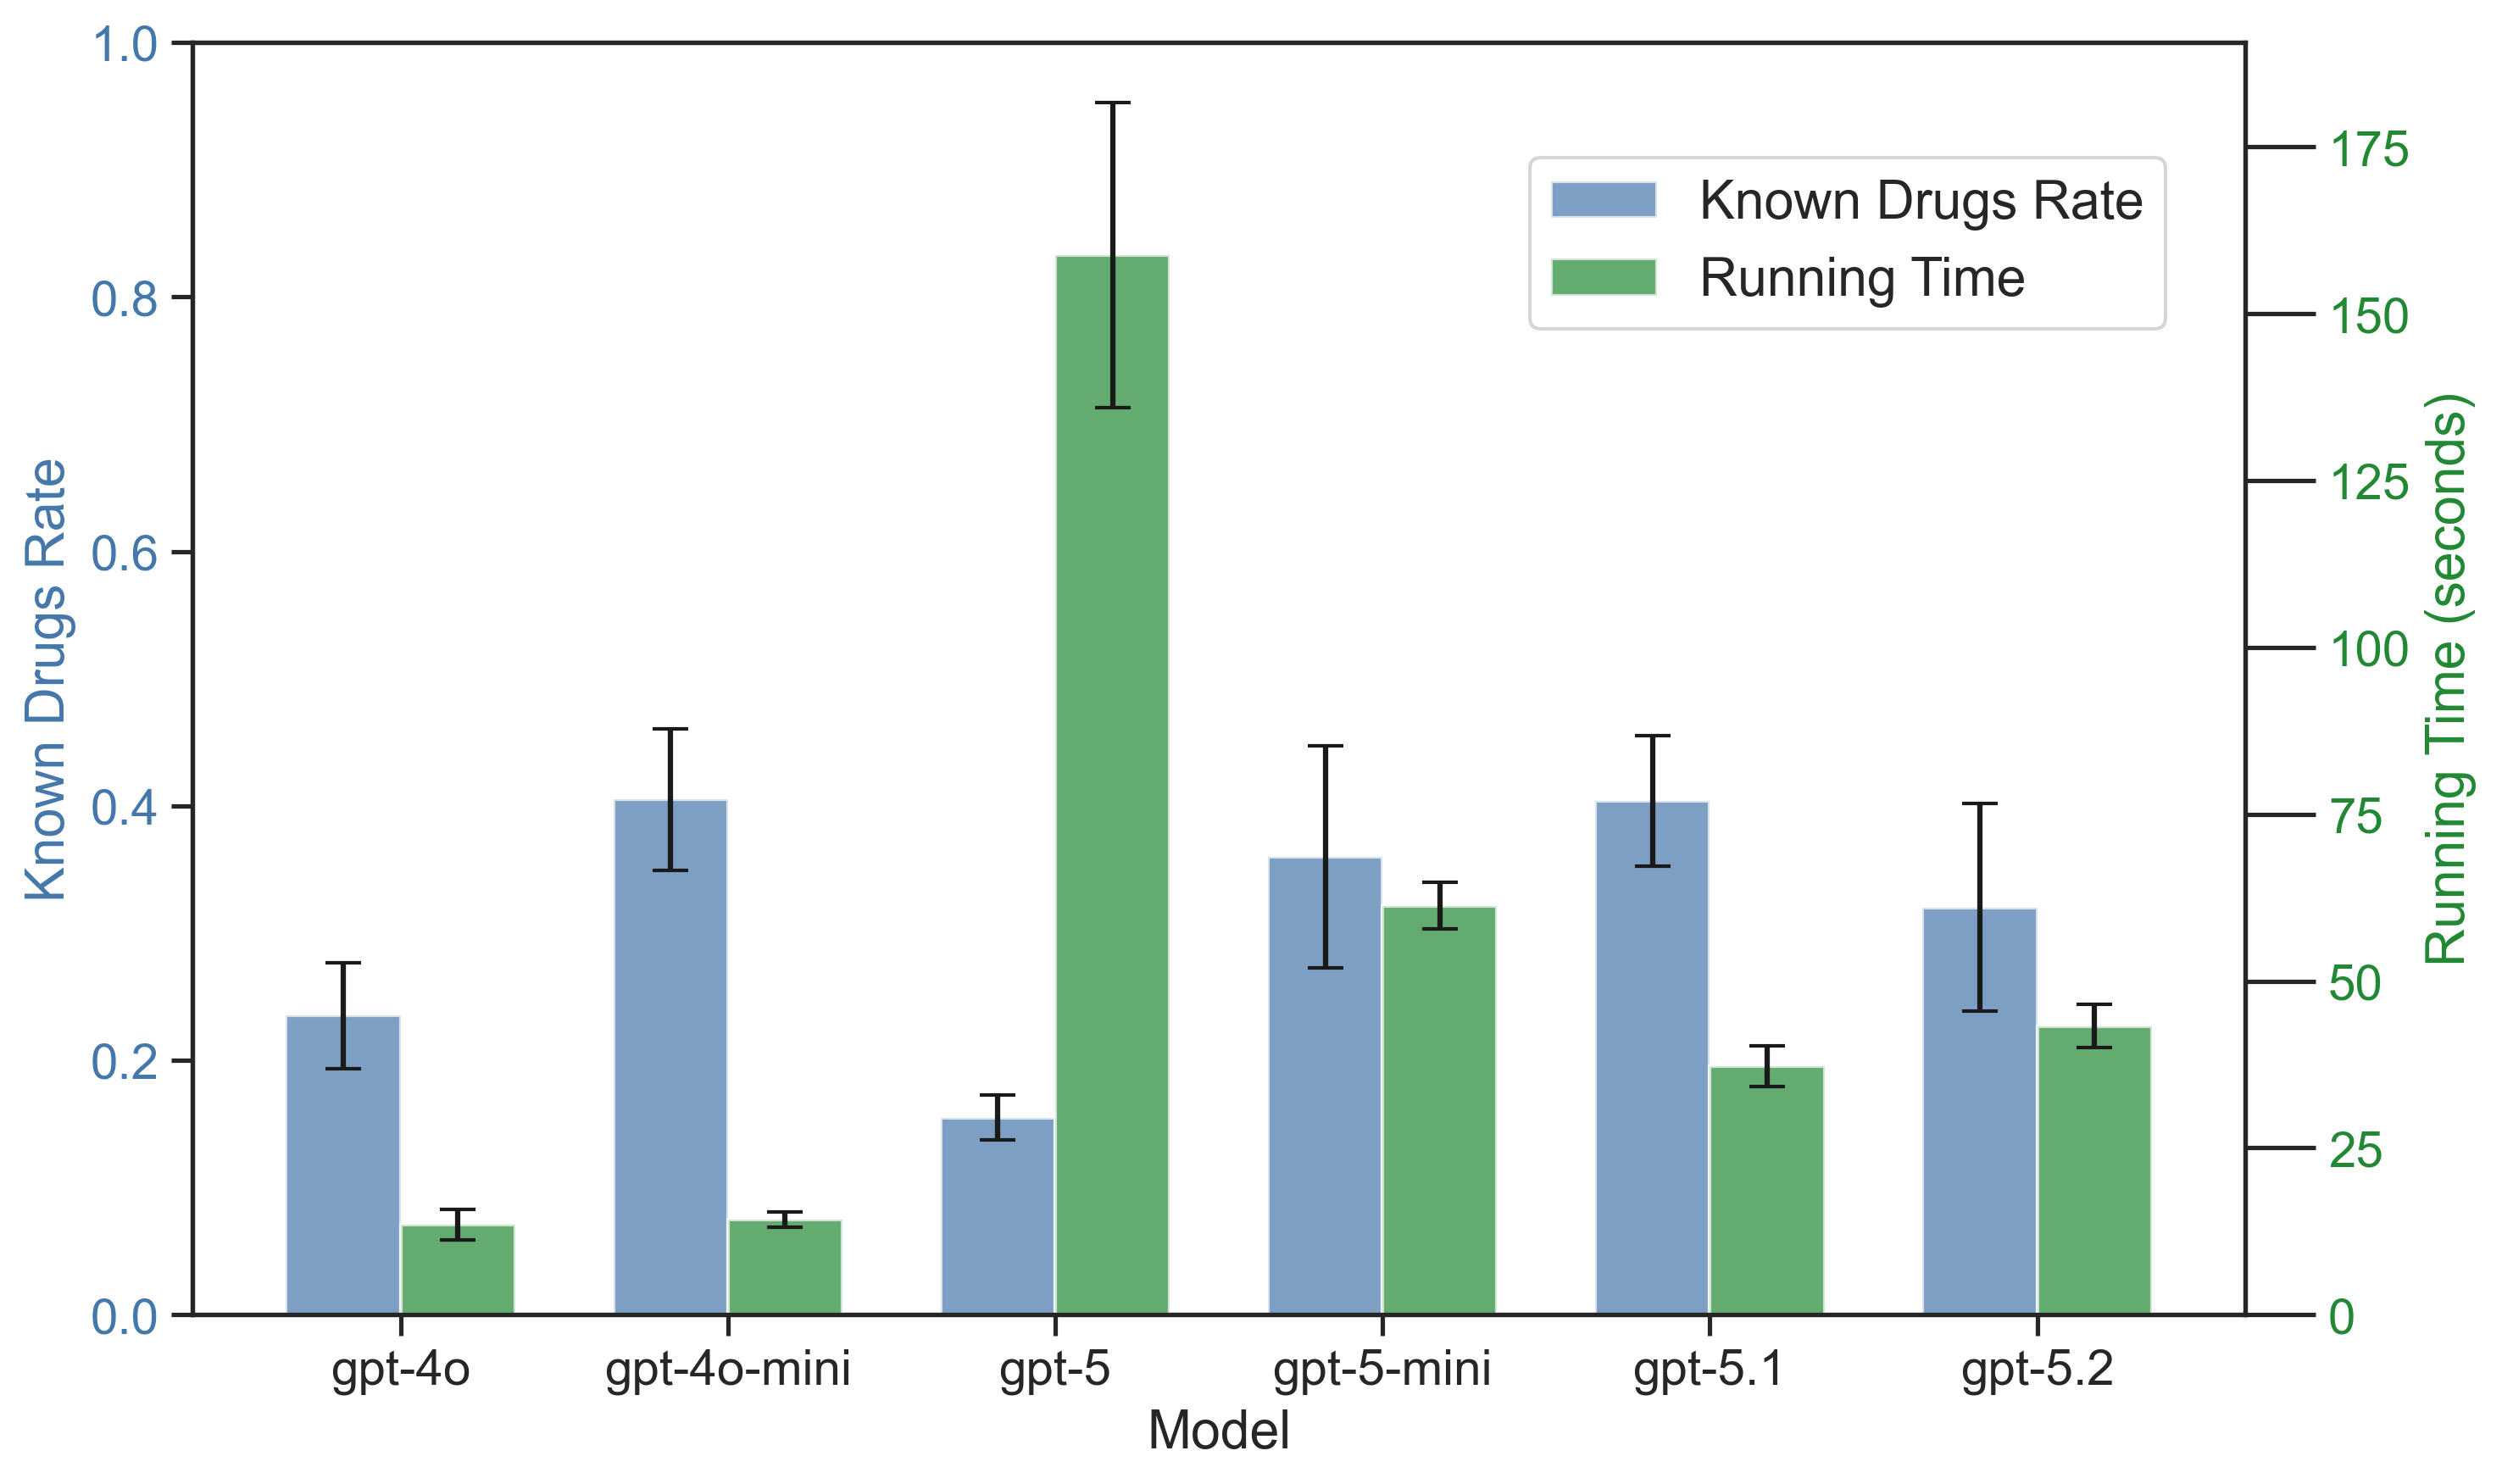

In [6]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Get unique models and create positions
models = results_summary['model'].unique()
x_pos = np.arange(len(models))
width = 0.35

# Calculate means and CIs for match_rate
match_means = results_summary.groupby('model')['match_rate'].mean()
match_ci = results_summary.groupby('model')['match_rate'].sem() * 1.96  # 95% CI

# Plot match_rate on left y-axis
bars1 = ax1.bar(x_pos - width/2, match_means, width, 
                yerr=match_ci, alpha=0.7, color=COLORS[0], 
                label='Known Drugs Rate', capsize=5)
ax1.set_ylabel('Known Drugs Rate', color=COLORS[0], fontsize=15)
ax1.tick_params(axis='y', labelcolor=COLORS[0], labelsize=14)
ax1.set_ylim(0, 1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models)
ax1.set_xlabel('Model', fontsize=15)
ax1.tick_params(axis='x', labelsize=14)

# Create secondary y-axis
ax2 = ax1.twinx()

# Calculate means and CIs for running_time
time_means = results_summary.groupby('model')['running_time_seconds'].mean()
time_ci = results_summary.groupby('model')['running_time_seconds'].sem() * 1.96  # 95% CI

# Plot running_time on right y-axis
bars2 = ax2.bar(x_pos + width/2, time_means, width, 
                yerr=time_ci, alpha=0.7, color=COLORS[2], 
                label='Running Time', capsize=5)
ax2.set_ylabel('Running Time (seconds)', color=COLORS[2], fontsize=15)
ax2.tick_params(axis='y', labelcolor=COLORS[2], size=20, labelsize=14)

# Add grid and legend
fig.legend(loc='upper right', bbox_to_anchor=(0.87, 0.9), fontsize=15)
plt.tight_layout()
plt.show()

## Part 2: Repuragent outputs analysis

In [69]:
# Load data
moa_df = pd.read_csv('repuragent_output10/mechanism_drug_candidate.csv')
pathways_df = pd.read_csv('repuragent_output10/pathway_drug_candidates.csv')
protein_df = pd.read_csv('repuragent_output10/protein_drug_candidates.csv')
candidates_csv = pd.read_csv('repuragent_output10/master_ranked.csv')
#candidates_csv['drug_name'] = candidates_csv['drug_name_final']

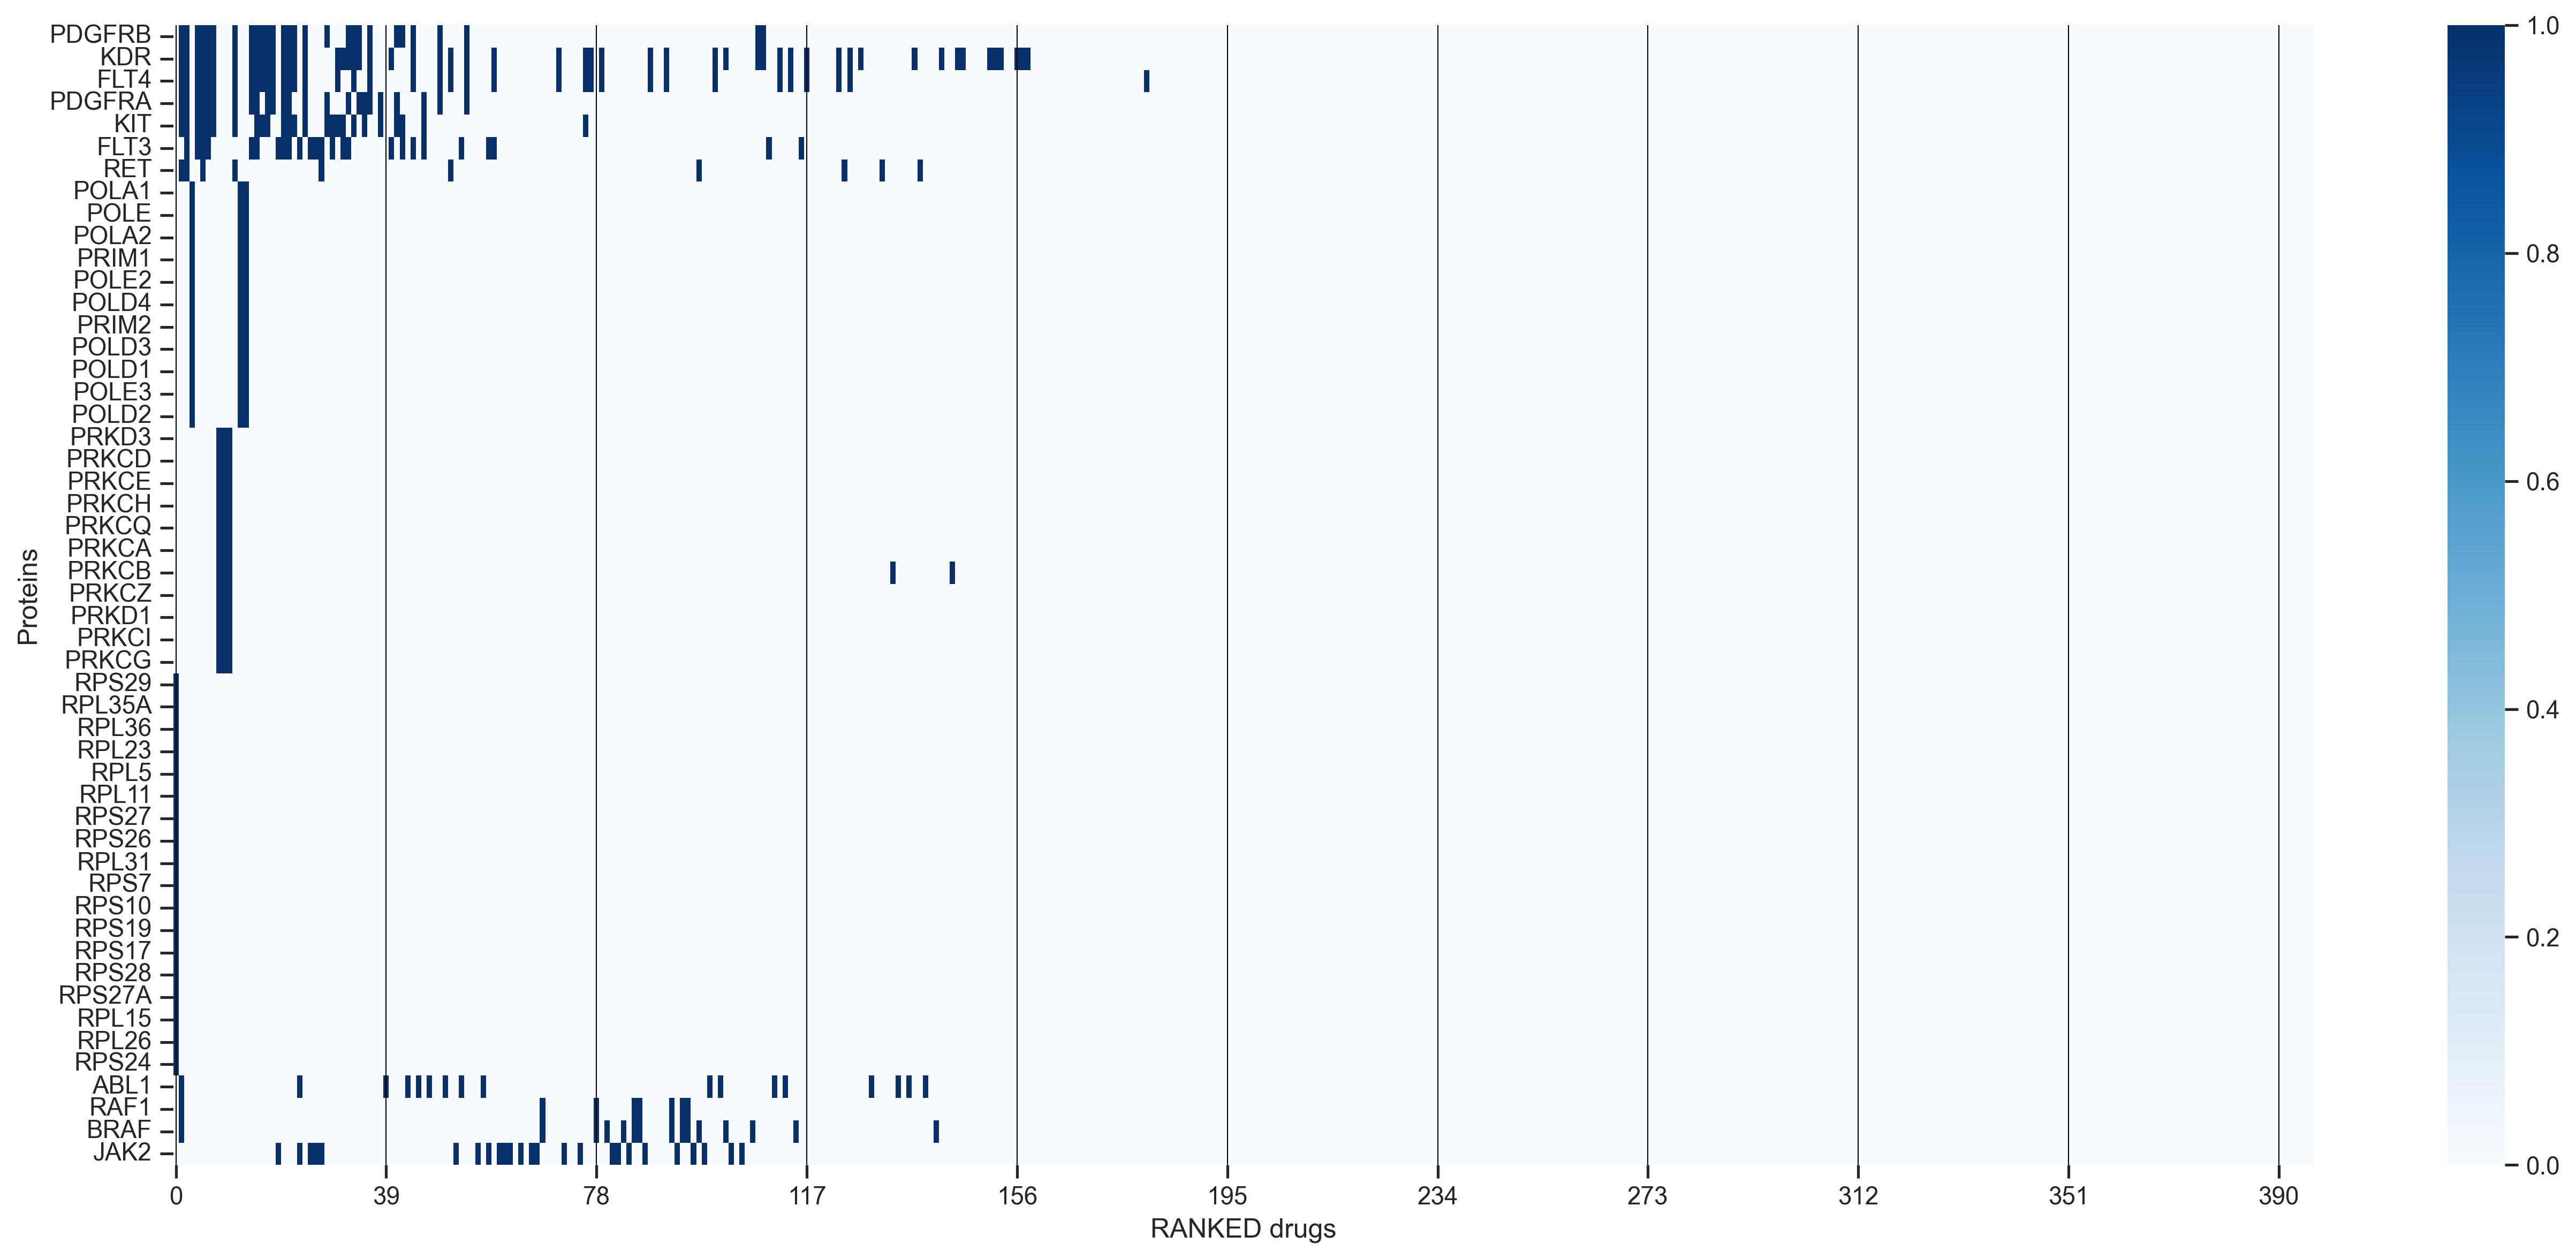

In [70]:
# Parameters: Set k and top_n_proteins here
k = 20 # Number of top-ranked drugs to use for protein selection
top_n_proteins = 100  # Number of most frequent proteins to display (selected from top k drugs)

# Get top k drugs to analyze protein frequencies
top_k_drugs = candidates_csv.head(k).copy()

# Count protein frequencies in top k drugs only (for selection)
protein_counts = {}
for idx, drug_row in top_k_drugs.iterrows():
    drug_chembl_id = drug_row['chembl_id']
    drug_proteins = protein_df[protein_df['chembl_id'] == drug_chembl_id]['gene_symbol'].values
    for protein in drug_proteins:
        protein_counts[protein] = protein_counts.get(protein, 0) + 1

# Get top n most frequent proteins (selected from top k drugs)
sorted_proteins = sorted(protein_counts.items(), key=lambda x: x[1], reverse=True)
top_proteins = [p[0] for p in sorted_proteins[:top_n_proteins]]

if len(top_proteins) == 0:
    print("No proteins found in top k drugs.")
else:
    # Create binary matrix for ALL drugs in candidates_csv, but only show top n proteins
    heatmap_data = []
    for idx, drug_row in candidates_csv.iterrows():
        drug_chembl_id = drug_row['chembl_id']
        # Find all proteins associated with this drug
        drug_proteins = protein_df[protein_df['chembl_id'] == drug_chembl_id]['gene_symbol'].values
        # Create binary vector: 1 if drug targets protein, 0 otherwise
        binary_vector = [1 if protein in drug_proteins else 0 for protein in top_proteins]
        heatmap_data.append(binary_vector)
    
    # Convert to numpy array
    heatmap_matrix = np.array(heatmap_data)
    
    # Create DataFrame for easier plotting
    heatmap_df = pd.DataFrame(
        heatmap_matrix,
        index=candidates_csv['drug_name'],  # Use drug names as row labels (ALL drugs)
        columns=top_proteins
    )
    
    # Plot heatmap (more compact: proteins on y-axis, drugs on x-axis)
    plt.figure(figsize=(18, 8))
    
    # Transpose so y-axis = proteins, x-axis = drugs
    heatmap_df_T = heatmap_df.T
    
    sns.heatmap(
        heatmap_df_T,
        cmap='Blues',
        cbar=True,
        xticklabels=False,  # Skip individual drug labels on x-axis
        yticklabels=True,   # Show protein labels on y-axis
        linecolor='#cccccc'
    )
    
    # Add vertical lines and numeric markers
    n_drugs = heatmap_df_T.shape[1]
    step = max(10, n_drugs // 10)  # Adaptive step size
    positions = [i + 0.5 for i in range(0, n_drugs + 1, step)]
    labels = [str(i) for i in range(0, n_drugs + 1, step)]
    
    for x in positions:
        plt.axvline(x, color='black', linewidth=0.5)
    
    plt.xticks(positions, labels)
    plt.xlabel('RANKED drugs', fontsize=12)
    plt.ylabel('Proteins', fontsize=12)
    plt.tight_layout()
    plt.show()

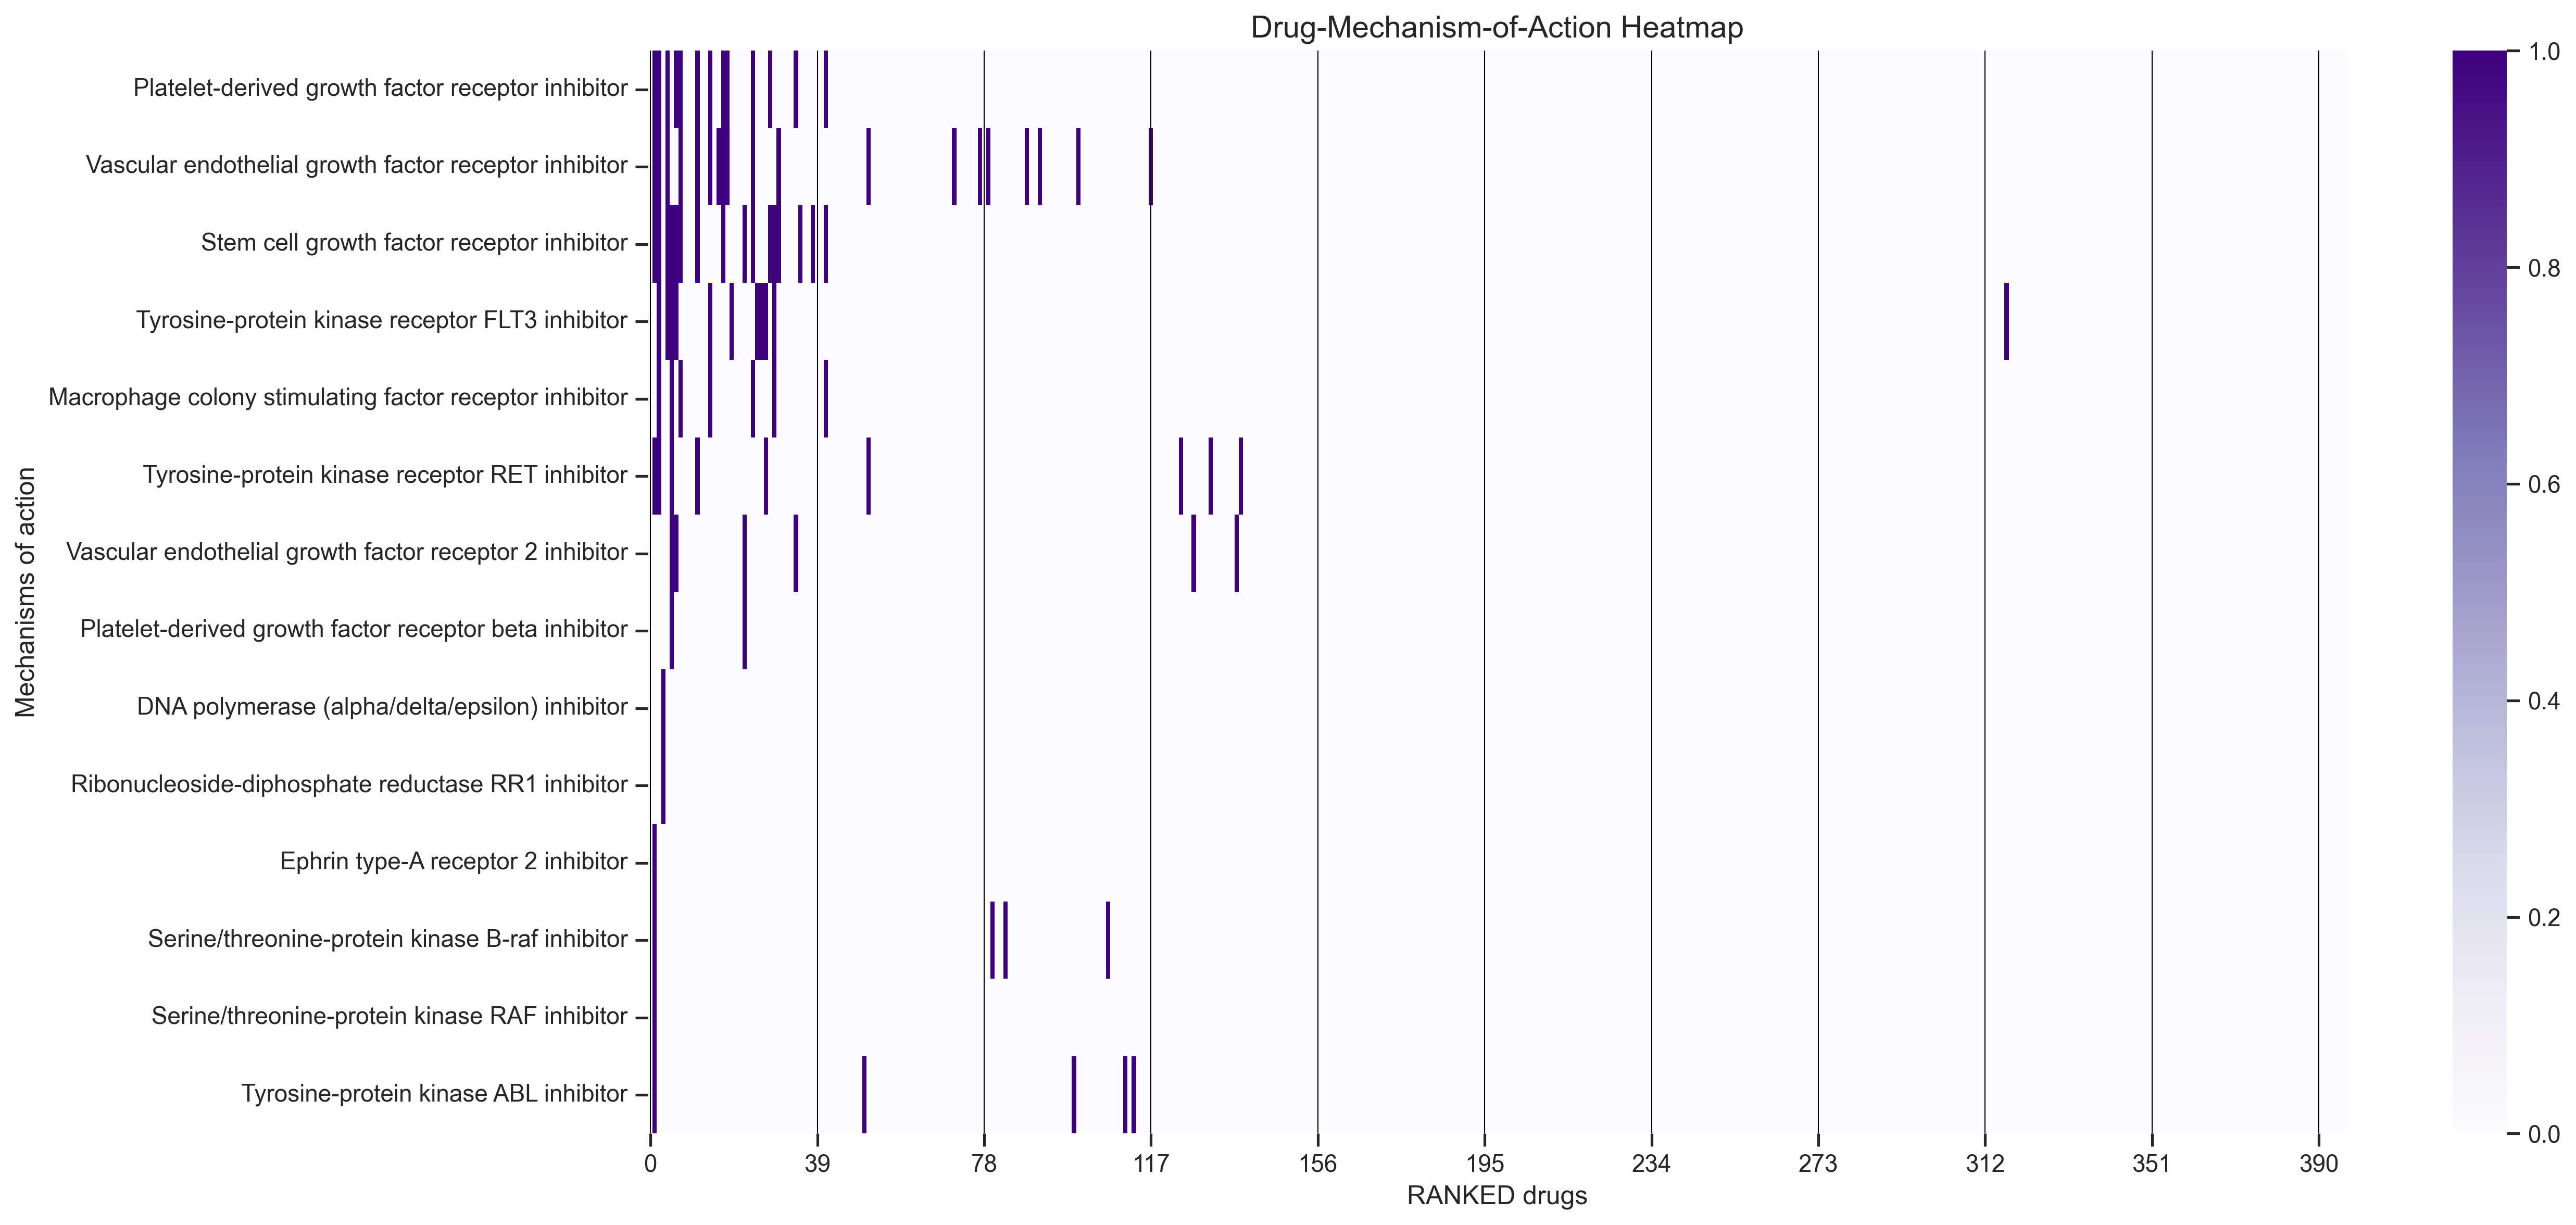

In [71]:
# Parameters: Use same k and top_n as protein heatmap, or set separately for MOA
k_moa = 20  # Number of top-ranked drugs to use for mechanism selection
top_n_mechs = 100  # Number of most frequent mechanisms to display (selected from top k drugs)

# Get top k drugs to analyze mechanism frequencies
top_k_drugs_moa = candidates_csv.head(k_moa).copy()
top_k_chembl_ids = set(top_k_drugs_moa['chembl_id'].values)

# Count mechanism frequencies in top k drugs only (for selection)
mech_counts = {}
for _, row in moa_df.iterrows():
    if row['chembl_id'] in top_k_chembl_ids:
        txt = row['mechanism_of_actions']
        if pd.notna(txt):
            for m in str(txt).split('|'):
                m = m.strip()
                if m:
                    mech_counts[m] = mech_counts.get(m, 0) + 1

# Get top n most frequent mechanisms (selected from top k drugs)
sorted_mechs = sorted(mech_counts.items(), key=lambda x: x[1], reverse=True)
top_mechs = [m[0] for m in sorted_mechs[:top_n_mechs]]

if len(top_mechs) == 0:
    print("No mechanisms found in top k drugs.")
else:
    # Create binary matrix for ALL drugs in candidates_csv, but only show top n mechanisms
    mech_heatmap_data = []
    for _, drug_row in candidates_csv.iterrows():
        drug_chembl_id = drug_row['chembl_id']
        # All mechanism strings for this drug
        moa_texts = moa_df[moa_df['chembl_id'] == drug_chembl_id]['mechanism_of_actions'].dropna().tolist()
        # Split and collect mechanisms for this drug
        drug_mechs = set()
        for txt in moa_texts:
            for m in str(txt).split('|'):
                m = m.strip()
                if m:
                    drug_mechs.add(m)
        # Binary vector over top n mechanisms only
        binary_vector = [1 if mech in drug_mechs else 0 for mech in top_mechs]
        mech_heatmap_data.append(binary_vector)
    
    # Convert to numpy array
    mech_heatmap_matrix = np.array(mech_heatmap_data)
    
    # Create DataFrame for easier plotting
    mech_heatmap_df = pd.DataFrame(
        mech_heatmap_matrix,
        index=candidates_csv['drug_name'],  # Use drug names as row labels (ALL drugs)
        columns=top_mechs                    # Top n mechanisms only
    )
    
    # Plot heatmap (mechanisms on y-axis, drugs on x-axis)
    plt.figure(figsize=(18, 8))
    
    # Transpose: y-axis = mechanisms, x-axis = drugs
    mech_heatmap_df_T = mech_heatmap_df.T
    
    sns.heatmap(
        mech_heatmap_df_T,
        cmap='Purples',
        cbar=True,
        xticklabels=False,  # Skip individual drug labels on x-axis
        yticklabels=True,   # Show mechanism labels on y-axis
    )
    
    # Add vertical lines and numeric markers
    n_drugs_mech = mech_heatmap_df_T.shape[1]
    step = max(10, n_drugs_mech // 10)  # Adaptive step size
    positions_mech = [i + 0.5 for i in range(0, n_drugs_mech + 1, step)]
    labels_mech = [str(i) for i in range(0, n_drugs_mech + 1, step)]
    
    for x in positions_mech:
        plt.axvline(x, color='black', linewidth=0.5)
    
    plt.xticks(positions_mech, labels_mech)
    plt.xlabel('RANKED drugs', fontsize=12)
    plt.ylabel('Mechanisms of action', fontsize=12)
    plt.title(f'Drug-Mechanism-of-Action Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()

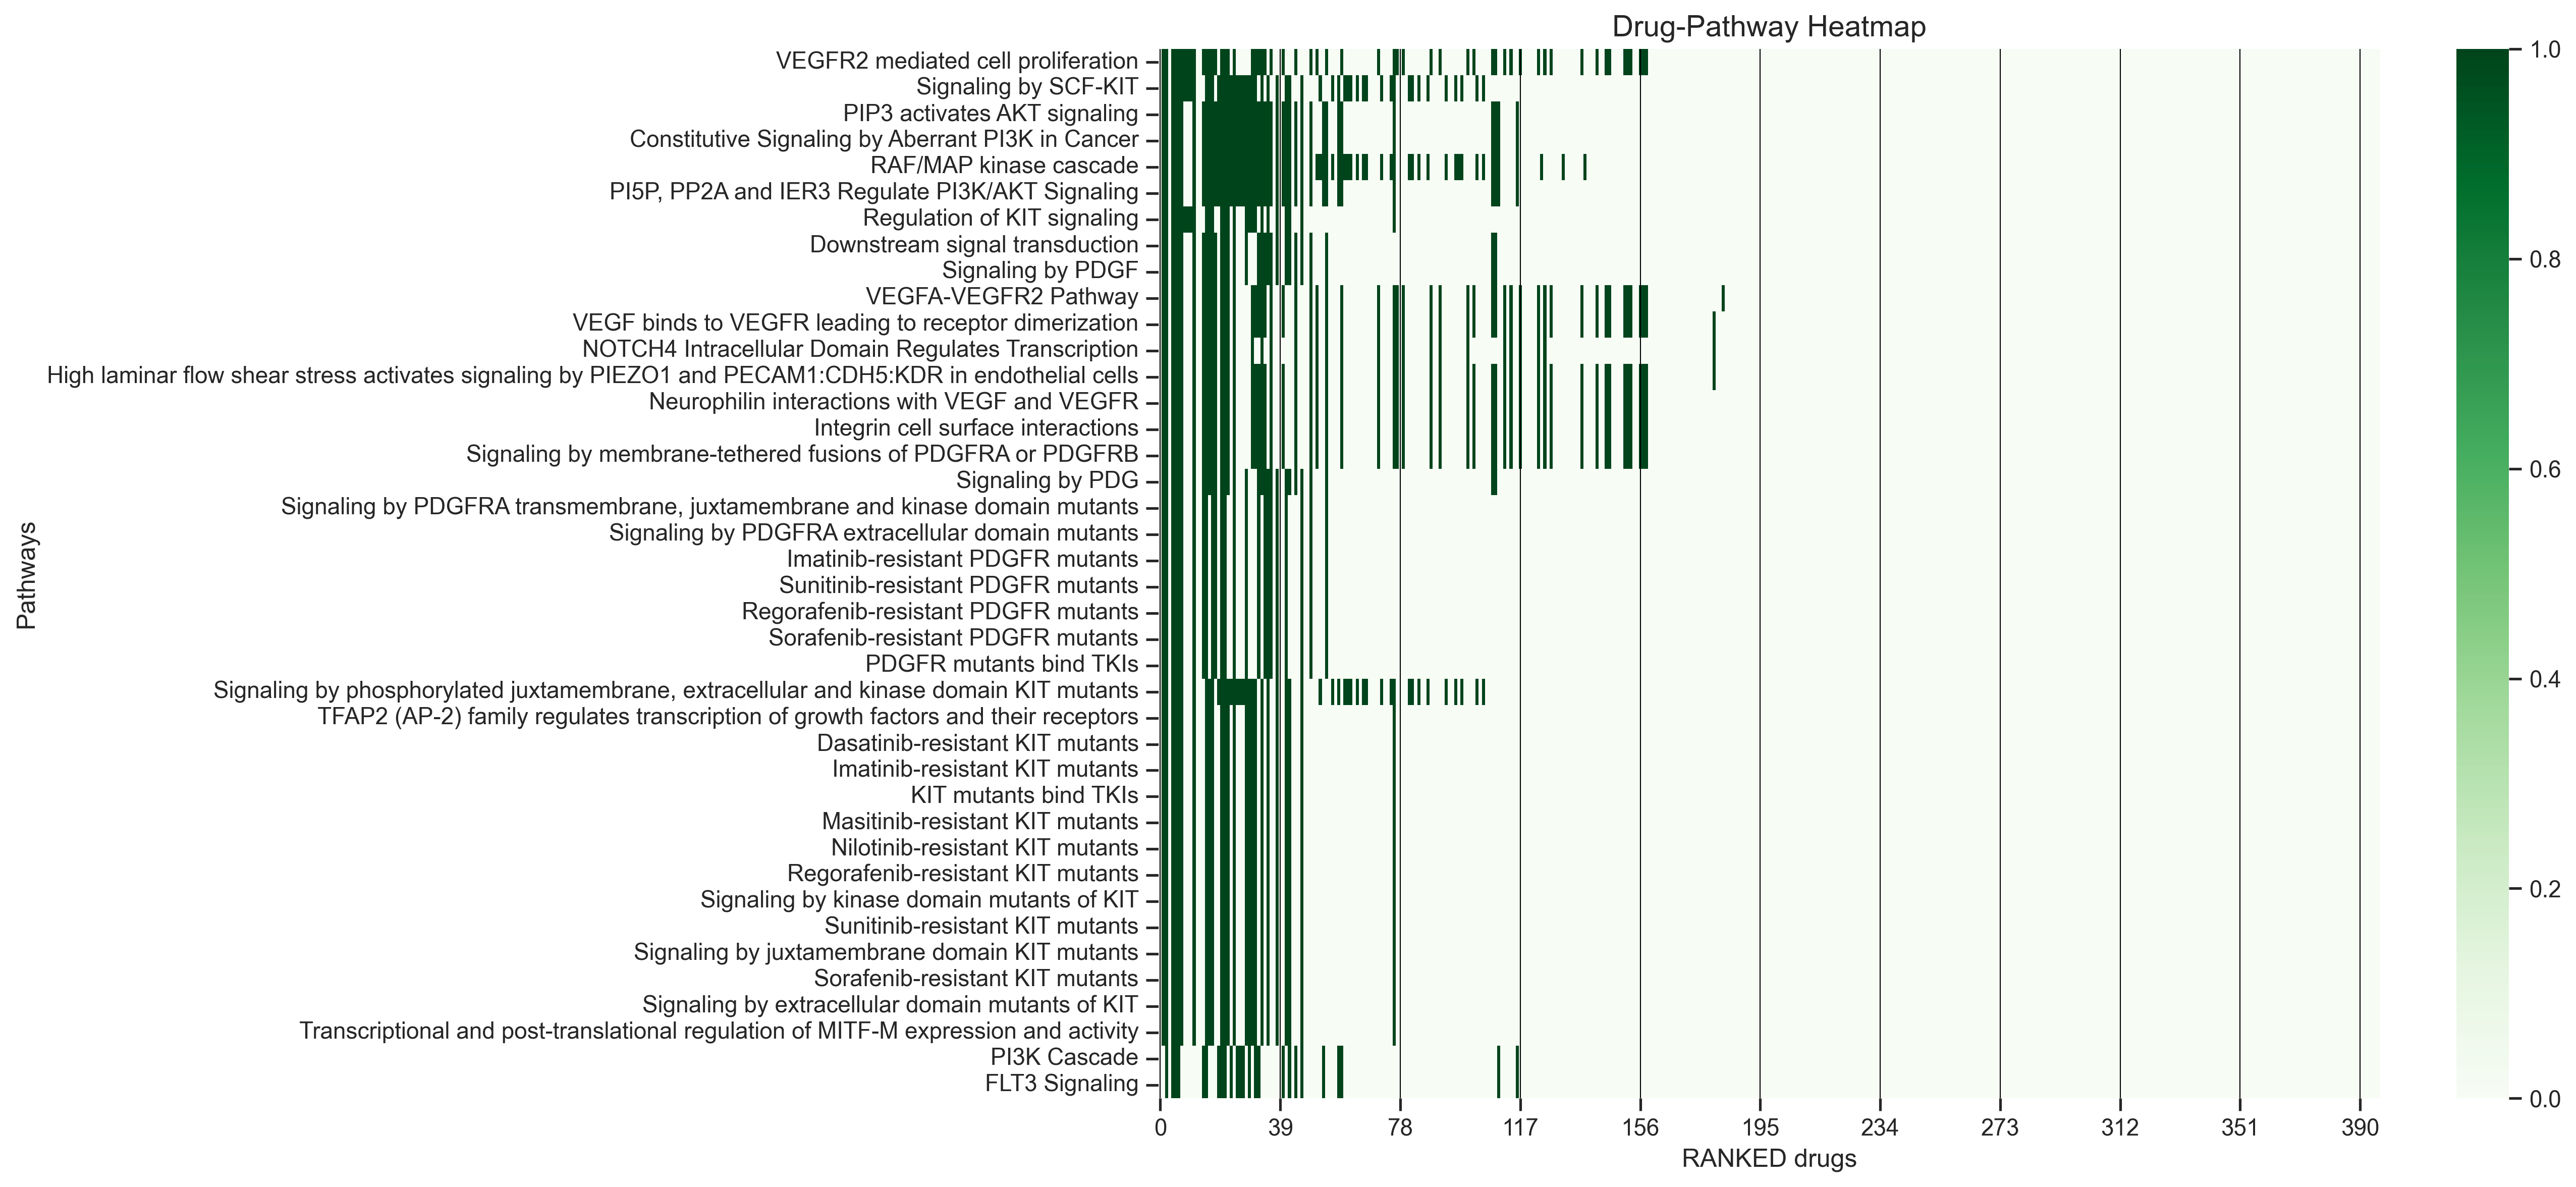

In [72]:
# --- Drug vs Pathway heatmap ---
# Parameters: Use same k and top_n as protein heatmap, or set separately for pathways
k_path = 20  # Number of top-ranked drugs to use for pathway selection
top_n_pathways = 40  # Number of most frequent pathways to display (selected from top k drugs)

# Get top k drugs to analyze pathway frequencies
top_k_drugs_path = candidates_csv.head(k_path).copy()
top_k_chembl_ids_path = set(top_k_drugs_path['chembl_id'].values)

# Count pathway frequencies in top k drugs only (for selection)
pathways_df = pathways_df.drop_duplicates(['chembl_id','pathway_id'])
pathway_counts = {}
for _, row in pathways_df.iterrows():
    if row['chembl_id'] in top_k_chembl_ids_path:
        pathway_name = row['pathway_name']
        if pd.notna(pathway_name):
            pathway_counts[pathway_name] = pathway_counts.get(pathway_name, 0) + 1

# Get top n most frequent pathways (selected from top k drugs)
sorted_pathways = sorted(pathway_counts.items(), key=lambda x: x[1], reverse=True)
top_pathways = [p[0] for p in sorted_pathways[:top_n_pathways]]
# Keep pathways in frequency order (most frequent first in list, will be at bottom of plot)

if len(top_pathways) == 0:
    print("No pathways found in top k drugs.")
else:
    # Create binary matrix for ALL drugs in candidates_csv, but only show top n pathways
    path_heatmap_data = []
    for _, drug_row in candidates_csv.iterrows():
        drug_chembl_id = drug_row['chembl_id']
        # All pathway names for this drug
        path_names = pathways_df[pathways_df['chembl_id'] == drug_chembl_id]['pathway_name'].dropna().unique()
        # Binary vector over top n pathways only
        binary_vector = [1 if p in path_names else 0 for p in top_pathways]
        path_heatmap_data.append(binary_vector)
    
    # Convert to numpy array
    path_heatmap_matrix = np.array(path_heatmap_data)
    
    # Create DataFrame for easier plotting
    path_heatmap_df = pd.DataFrame(
        path_heatmap_matrix,
        index=candidates_csv['drug_name'],  # Use drug names as row labels (ALL drugs)
        columns=top_pathways                # Top n pathways only
    )
    
    # Plot heatmap (pathways on y-axis, drugs on x-axis)
    plt.figure(figsize=(18, 8))
    
    # Transpose: y-axis = pathways, x-axis = drugs
    path_heatmap_df_T = path_heatmap_df.T
    
    sns.heatmap(
        path_heatmap_df_T,
        cmap='Greens',
        cbar=True,
        xticklabels=False,  # Skip individual drug labels on x-axis
        yticklabels=True,   # Show pathway labels on y-axis
    )
    
    # Add vertical lines and numeric markers
    n_drugs_path = path_heatmap_df_T.shape[1]
    step = max(10, n_drugs_path // 10)  # Adaptive step size
    positions_path = [i + 0.5 for i in range(0, n_drugs_path + 1, step)]
    labels_path = [str(i) for i in range(0, n_drugs_path + 1, step)]
    
    for x in positions_path:
        plt.axvline(x, color='black', linewidth=0.5)
    
    plt.xticks(positions_path, labels_path)
    plt.xlabel('RANKED drugs', fontsize=12)
    plt.ylabel('Pathways', fontsize=12)
    plt.title(f'Drug-Pathway Heatmap', fontsize=14)
    plt.tight_layout()
    plt.show()

# Part 3: Pathway enrichment and comparison to Co-scientist

## 3.1. Pathway enrichment pipeline for each model and each run

In [ ]:
# Define models to test
models_to_test = [
    'gpt-4o',
    'gpt-4o-mini',
    'gpt-5',
    'gpt-5-mini',
    'gpt-5.1',
    'gpt-5.2',
]

# Cache
CACHE_DIR = "cache_pathway_overlap"
os.makedirs(CACHE_DIR, exist_ok=True)      


# Initialize results dictionary
results_dict = {
    'model': [],
    'jaccard': [],
    'recall': [],
    'precision': [],
    'iteration': []
}


# Co-scientist: compute pathways
co_df = pd.read_csv('co-scientist-output/top_drugs.csv')
P_co = pathways_enrichment_from_chembl_id(co_df)


# For repuragent
for i in range(1, 11):
    print(f"Processing iteration: {i}")

    # Construct file path
    input_path =  f"repuragent_output{i}/top20_selected.csv"
    
    # Load top-N drugs
    rep_drugs_df = pd.read_csv(input_path)
    
    # Compute pathways
    P_rep = pathways_enrichment_from_chembl_id(rep_drugs_df)
    

    # Compute metrics
    jaccard_score = jaccard(P_rep, P_co)
    recall = len(P_rep & P_co) / len(P_co)
    precision = len(P_rep & P_co) / len(P_rep)

    print(f"Jaccard: {jaccard_score:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
    
    # Store results
    results_dict['model'].append('Repuragent')
    results_dict['jaccard'].append(jaccard_score)
    results_dict['recall'].append(recall)
    results_dict['precision'].append(precision)
    results_dict['iteration'].append(i)

# Process each model
for model in models_to_test:
    
    for i in range(1, 11):
        print(f"Model: {model}, Iteration: {i}")
        
        # Read and process CSV     
        input_path = f'vanila_LLM_output/results_filtered_{model}_{i}.csv'

        drugs_df = pd.read_csv(input_path)
        
        P_vanilla = pathways_enrichment_from_chembl_id(drugs_df)


        # Compute metrics
        jaccard_score = jaccard(P_vanilla, P_co)
        recall = len(P_vanilla & P_co) / len(P_co)
        precision = len(P_vanilla & P_co) / len(P_vanilla)
        
        print(f"  ✓ Jaccard: {jaccard_score:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
        
        # Append to results dictionary
        results_dict['model'].append(model)
        results_dict['jaccard'].append(jaccard_score)
        results_dict['recall'].append(recall)
        results_dict['precision'].append(precision)
        results_dict['iteration'].append(i)

    results_df = pd.DataFrame(results_dict)
    results_df.to_csv('pathway_compare_results.csv', index=False)



# Convert dictionary to DataFrame
results_df = pd.DataFrame(results_dict)

# Save results
results_df.to_csv('pathway_compare_results.csv', index=False)

# 3.2. Random seelction baseline

In [42]:
# Randomize
df = pd.read_csv('random_output/cancer_drugs_chembl.csv')
rng = np.random.default_rng(1357)  
seeds = rng.integers(0, 10000, 10)   

for n, seed in enumerate(seeds,start=1): 
    df_random = df.sample(n=20, random_state=seed)
    df_random.to_csv(f'random_output/random_output{n}.csv', index=False)

In [ ]:
co_df = pd.read_csv('co-scientist-output/top_drugs.csv')
P_co = pathways_enrichment_from_chembl_id(co_df)

# Load pathway_compare summary
df = pd.read_csv('pathway_compare_results.csv')
results_dict = df.to_dict(orient='list')


# For random_baseline
for i in range(1, 11):
    print(f"Processing iteration: {i}")

    # Construct file path
    input_path =  f"random_output/random_output{i}.csv"
    
    # Load top-N drugs
    drugs_df = pd.read_csv(input_path)
    
    # Compute pathways
    P_rep = pathways_enrichment_from_chembl_id(drugs_df)
    

    # Compute metrics
    jaccard_score = jaccard(P_rep, P_co)
    recall = len(P_rep & P_co) / len(P_co)
    precision = len(P_rep & P_co) / len(P_rep) if len(P_rep) != 0 else float('nan')

    print(f"Jaccard: {jaccard_score:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")
    
    # Store results
    results_dict['model'].append('Random cancer drugs')
    results_dict['jaccard'].append(jaccard_score)
    results_dict['recall'].append(recall)
    results_dict['precision'].append(precision)
    results_dict['iteration'].append(i)

results_df = pd.DataFrame(results_dict)
results_df.to_csv('pathway_compare_results.csv', index=False)

## 3.2. Statistical test to compare models

       metric         ref                other     kruskal_p     p_raw  \
14    jaccard  Repuragent               gpt-4o  4.932877e-04  0.000769   
15    jaccard  Repuragent          gpt-4o-mini  4.932877e-04  0.000183   
16    jaccard  Repuragent                gpt-5  4.932877e-04  0.000182   
17    jaccard  Repuragent           gpt-5-mini  4.932877e-04  0.000183   
18    jaccard  Repuragent              gpt-5.1  4.932877e-04  0.000182   
19    jaccard  Repuragent              gpt-5.2  4.932877e-04  0.000183   
20    jaccard  Repuragent  Random cancer drugs  4.932877e-04  0.000183   
8   precision  Repuragent          gpt-4o-mini  3.474462e-04  0.000183   
9   precision  Repuragent                gpt-5  3.474462e-04  0.000182   
10  precision  Repuragent           gpt-5-mini  3.474462e-04  0.000183   
11  precision  Repuragent              gpt-5.1  3.474462e-04  0.000182   
12  precision  Repuragent              gpt-5.2  3.474462e-04  0.000183   
7   precision  Repuragent             

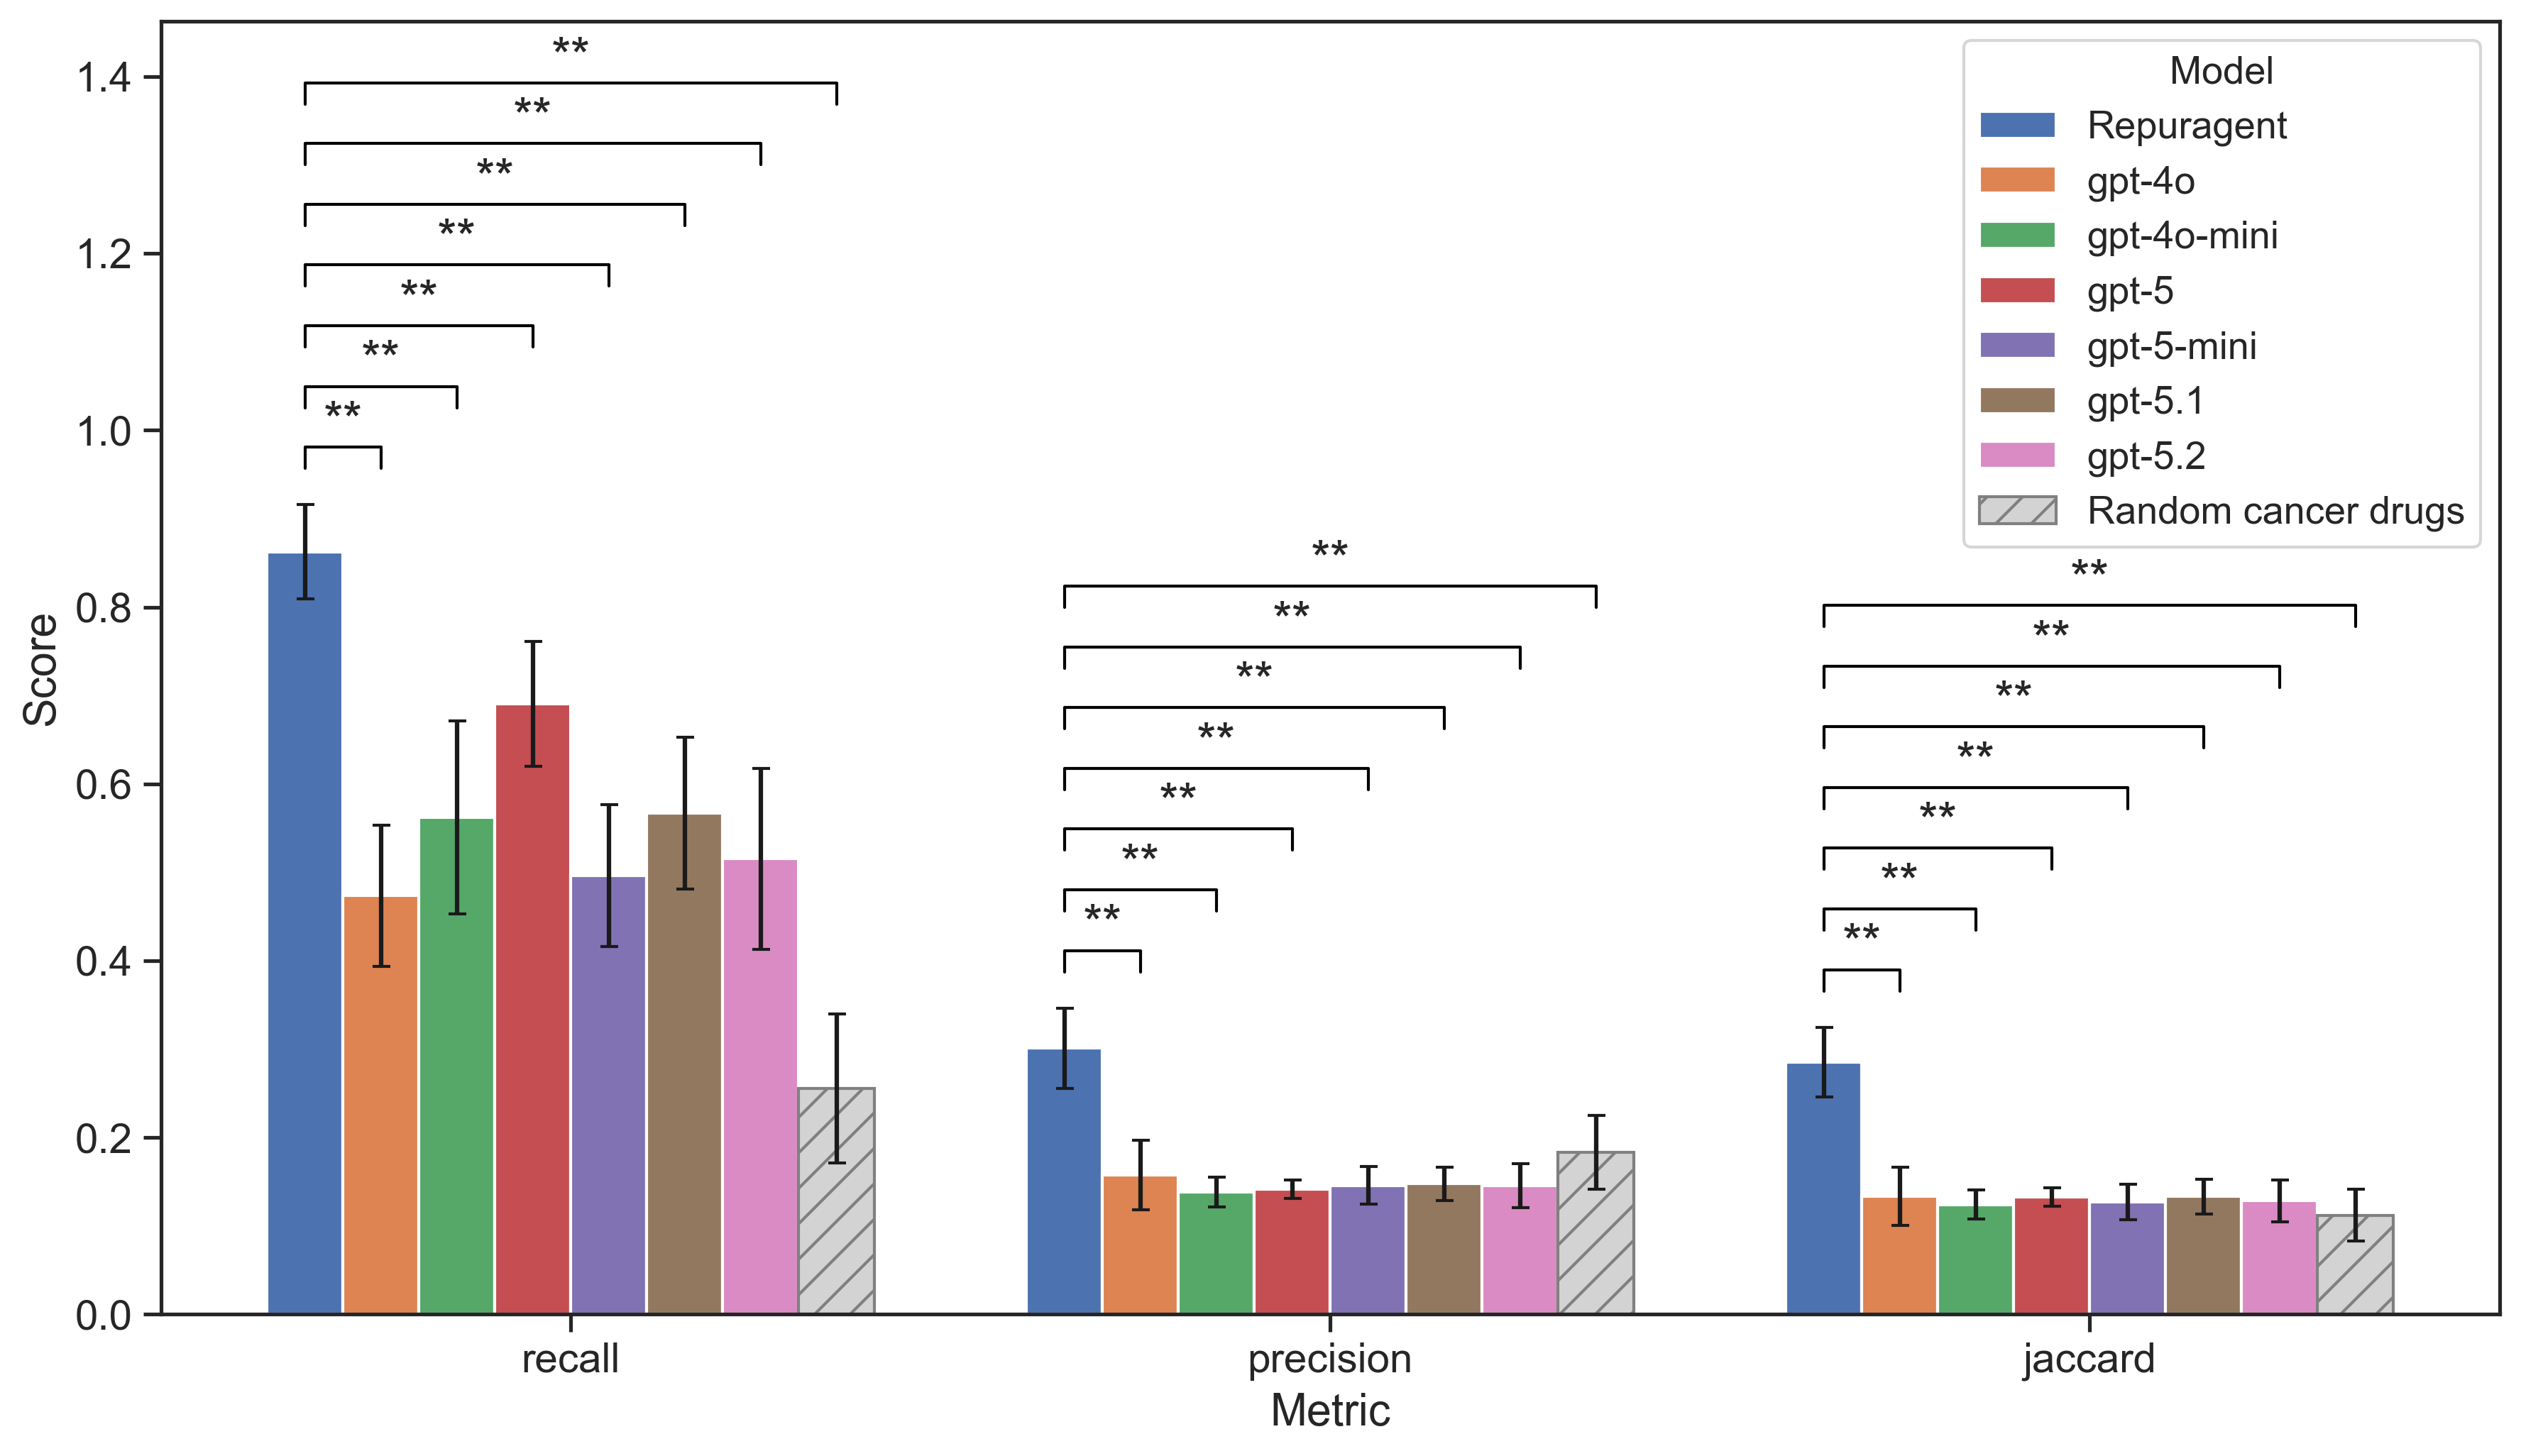

In [3]:
# Draw pathway comparision plot 
df = pd.read_csv("pathway_compare_results.csv")

stats, summary = nonparametric_repuragent_tests(
    df,
    metrics=("recall", "precision", "jaccard"),
    ref_model="Repuragent",
    p_adjust="holm",
)

print(summary)  # view results table

fig, ax = plot_grouped_bars_with_repuragent_significance(
    df,
    stats,
    metrics=("recall", "precision", "jaccard"),
    ref_model="Repuragent",
    err="ci95",        # Use 95% confidence interval
)

plt.show()

## 3.3. Pathway overlap visualization


In [12]:
# Paths + inputs
REPURAGENT_OUTPUT = "repuragent_output10/top20_selected.csv"
REP_TOP_N = 20  # how many top repuragent drugs to take

CO_SCIENTIST_OUTPUT = "co-scientist-output/top_drugs.csv"
CO_DRUGS = pd.read_csv(CO_SCIENTIST_OUTPUT)

# Repuragent enrichment
rep_drugs_df = pd.read_csv(REPURAGENT_OUTPUT)
P_rep= pathways_enrichment_from_chembl_id(
    rep_drugs_df)

# Co-scientist enrichment
co_drugs_df = pd.read_csv(CO_SCIENTIST_OUTPUT)
P_co = pathways_enrichment_from_chembl_id(co_drugs_df
)

# Summary
print("=== Summary ===")
print(f"Repuragent top-{REP_TOP_N} drugs: {len(rep_drugs_df)}")
print(f"Repuragent pathways: {len(P_rep)}")
print(f"Co-scientist drugs: {len(CO_DRUGS)}")
print(f"Co-scientist pathways: {len(P_co)}")
print(f"Shared pathways: {len(P_rep & P_co)}")
print(f"Jaccard overlap: {jaccard(P_rep, P_co)}")
print(f"Cosine overlap:  {cosine_binary(P_rep, P_co)}")

# Sankey: aggregated overlap
fig1 = sankey_aggregated(
    P_rep, P_co,
    title=f"Pathway overlap (Aggregated): Repuragent top-{REP_TOP_N} vs Co-scientist\n"
)
fig1.show()


Annotating 20 drugs with target genes...
  1/20: ATALUREN (CHEMBL256997)
  2/20: REGORAFENIB (CHEMBL1946170)
  3/20: SUNITINIB MALATE (CHEMBL1567)
  4/20: GEMCITABINE HYDROCHLORIDE (CHEMBL1637)
  5/20: DOVITINIB (CHEMBL522892)
  6/20: SUNITINIB (CHEMBL535)
  7/20: FAMITINIB (CHEMBL1278146)
  8/20: PAZOPANIB HYDROCHLORIDE (CHEMBL1201733)
  9/20: SOTRASTAURIN (CHEMBL565612)
  10/20: GSK-690693 (CHEMBL494089)
  11/20: UCN-01 (CHEMBL574737)
  12/20: MOTESANIB (CHEMBL572881)
  13/20: TROXACITABINE (CHEMBL359164)
  14/20: ASPACYTARABINE (CHEMBL4297599)
  15/20: LINIFANIB (CHEMBL223360)
  16/20: SU-014813 (CHEMBL1721885)
  17/20: TIVOZANIB (CHEMBL1289494)
  18/20: CEDIRANIB (CHEMBL491473)
  19/20: NINTEDANIB ESYLATE (CHEMBL3039504)
  20/20: FEDRATINIB HYDROCHLORIDE (CHEMBL4297216)

Total unique targets found: 35
Drugs with ≥1 target: 20
Annotating 8 drugs with target genes...
  1/8: Binimetinib (CHEMBL3187723)
  2/8: Pacritinib (CHEMBL2035187)
  3/8: Cerivastatin (CHEMBL1477)
  4/8: Pravastat

In [13]:
P_rep & P_co

{'Axon Guidance R-HSA-422475',
 'Chromatin Modifying Enzymes R-HSA-3247509',
 'Constitutive Signaling By Aberrant PI3K In Cancer R-HSA-2219530',
 'Cyclin D Associated Events In G1 R-HSA-69231',
 'Cytokine Signaling In Immune System R-HSA-1280215',
 'Developmental Biology R-HSA-1266738',
 'Disease R-HSA-1643685',
 'Diseases Of Signal Transduction By Growth Factor Receptors And Second Messengers R-HSA-5663202',
 'Erythropoietin Activates Phosphoinositide-3-kinase (PI3K) R-HSA-9027276',
 'Erythropoietin Activates Phospholipase C Gamma (PLCG) R-HSA-9027277',
 'Erythropoietin Activates RAS R-HSA-9027284',
 'Erythropoietin Activates STAT5 R-HSA-9027283',
 'FLT3 Signaling By CBL Mutants R-HSA-9706377',
 'FLT3 Signaling In Disease R-HSA-9682385',
 'FLT3 Signaling R-HSA-9607240',
 'FLT3 Signaling Thru SRC Family Kinases R-HSA-9706374',
 'Factors Involved In Megakaryocyte Development And Platelet Production R-HSA-983231',
 'Frs2-mediated Activation R-HSA-170968',
 'Growth Hormone Receptor Signal